# Combinatorial perturbation and departures from additivity

If two knockouts each push cells toward beta, does removing both push twice as hard? Only if the
two act independently. Where they do not, the joint effect departs from the sum of the singles,
and that departure is the interesting quantity: it is a statement about how two regulators combine
that neither single knockout contains.

The model gives it for free. A double knockout is the same evaluation as a single one with two
genes held at zero instead of one, so the joint prediction costs no more than the singles and
comes from exactly the same fitted system.

$$\varepsilon_{ab} \;=\; \Delta_{ab} \;-\; (\Delta_a + \Delta_b)$$

A positive $\varepsilon$ along a given axis means the pair pushes further together than
independently. A negative one means they get in each other's way.

This is the shortest tutorial, because it inherits everything from **Single-gene knockouts**. Read
that one first: the fate split, the decider cells and the meaning of a shift are all defined there.

**Runtime.** About forty seconds on top of the setup, on an RTX 3090.

## Setup: rebuild the object and load the fitted model

This tutorial starts from the checkpoint written by **Getting started**. Run that notebook first,
or copy its `pancreas_fitted.h5sch` next to this one.

The checkpoint holds the model and not the experiment: the interaction matrices, the bias and
degradation vectors, and the activation parameters. It does not hold the expression data, so the
cell-level object is rebuilt here from the same public download and the same recipe. That part
costs well under a minute and runs on a CPU. What it saves is the interaction fit, which is the
one step that wants a GPU.

The activation comes back with the network. `save_model` writes both Hill components of every
gene and the weight that mixes them, so `compute_sigmoid` after `load_model` rebuilds the
**two-component** activation the system was fitted with rather than a single Hill curve standing
in for it. Nothing is re-fitted here.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
import torch

import scHopfield as sch

scv.settings.verbosity = 0
sc.settings.verbosity = 0

CHECKPOINT = "pancreas_fitted.h5sch"
CLUSTER_KEY = "clusters"
ORDER = ["Ductal", "Ngn3 low EP", "Ngn3 high EP", "Pre-endocrine",
         "Alpha", "Beta", "Delta", "Epsilon"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"'{CHECKPOINT}' not found. Run the Getting started tutorial first: it fits the model "
        f"and writes this file.")

t0 = time.time()

# The same preparation as Getting started, section by section.
adata = scv.datasets.pancreas()
scv.pp.filter_genes(adata, min_shared_counts=20)
scv.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var["highly_variable"]].copy()
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.velocity(adata, mode="steady_state")

adata.layers["velocity_S"] = adata.layers["velocity"]
adata.var["gamma"] = adata.var["velocity_gamma"].astype(np.float32)
vel = np.asarray(adata.layers["velocity_S"])
keep = (np.isfinite(adata.var["gamma"].values)
        & np.isfinite(vel).all(axis=0)
        & (adata.var["gamma"].values > 0))
adata = adata[:, keep].copy()
adata.var["scHopfield_used"] = True

# Restore the fitted system from the checkpoint: the network and the activation both.
adata = sch.tl.load_model(adata, CHECKPOINT)
sch.pp.compute_sigmoid(adata, spliced_key="Ms")

print(f"setup: {time.time() - t0:.1f} s on a CPU")
print(adata.shape)
print("fitted systems:", sorted(k[2:] for k in adata.varp if k.startswith("W_")))

/tmp/ipykernel_610157/2386655385.py:36: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/bernaljp/Documents/SCH/.venv/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


Model loaded from 'pancreas_fitted.h5sch'  |  clusters=['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']  |  genes=2000


setup: 12.7 s on a CPU
(3696, 2000)
fitted systems: ['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']


The checkpoint and the rebuild have to describe the same genes in the same order, or the model
would be loaded onto the wrong ones. `load_model` raises if a gene the model needs is absent, and
warns if the file predates the activation being stored in full. Neither fires above, so the
activation in use is the fitted one, and it is worth seeing how much of it is genuinely
two-component.

In [2]:
n_bimodal = int((adata.var["sigmoid_mix"].values < 1 - 1e-9).sum())
print(f"activation fitted with two components: {adata.uns['scHopfield']['sigmoid_bimodal']}")
print(f"genes with a real second activation component: {n_bimodal} / {adata.n_vars}")

activation fitted with two components: True
genes with a real second activation component: 629 / 2000


## 1. Two decisions, not one

Pancreatic endocrinogenesis is a multifurcation, so a single fate axis does not describe it. Two
are used here, and they answer different questions:

- **alpha against beta**, the choice between two mature endocrine fates, and
- **differentiated against progenitor**, which asks whether a perturbation blocks differentiation
  and holds cells back rather than steering them sideways.

A pair can be super-additive on one axis and buffering on the other, which is why both are
computed rather than one.

`fate_scaffold` precomputes the wild-type quantities that every perturbed evaluation reuses, so
the singles and the doubles are all scored against the same baseline.

In [3]:
DIFFERENTIATED = ["Alpha", "Beta", "Delta", "Epsilon"]
PROGENITOR = ["Ductal", "Ngn3 low EP", "Ngn3 high EP"]

lineage_pairs = [
    (["Alpha"], ["Beta"], "alpha", "beta"),
    (DIFFERENTIATED, PROGENITOR, "differentiated", "progenitor"),
]

# Which cells count as still undecided, per decision. Pancreas names these populations, so they
# are given explicitly rather than left to the data-driven fallback.
TRANSITIONAL = {
    ("alpha", "beta"): ["Pre-endocrine"],
    ("differentiated", "progenitor"): ["Ngn3 high EP", "Pre-endocrine"],
}

t0 = time.time()
scaffold_fate = sch.tl.fate_scaffold(adata, CLUSTER_KEY, lineage_pairs, basis="umap")
axes = sch.tl.lineage_pair_axes(scaffold_fate, lineage_pairs, TRANSITIONAL)
print(f"fate scaffold: {time.time() - t0:.1f} s")
for key, ax in axes.items():
    print(f"  {key[0]} vs {key[1]}: {int(ax['focus'].sum())} decider cells")

fate scaffold: 2.9 s
  alpha vs beta: 592 decider cells
  differentiated vs progenitor: 1234 decider cells


## 2. The curated pairs

This is deliberately not a screen. The full pairwise screen behind the paper's combinatorial
figure takes a candidate pool into roughly two hundred pairs, which is a batch job rather than a
tutorial. The four pairs below are the ones the paper reports, and running them explicitly shows
the calculation without hiding it inside a sweep.

Every gene involved has to be in the fitted gene set and has to regulate something, for the reason
the single-knockout tutorial demonstrates: a gene with no outgoing edges returns exactly zero.

In [4]:
PAIRS = [("Arx", "Neurod1"), ("Neurod1", "Eno1"), ("Rfx6", "Klf10"), ("Vdr", "Xbp1")]

singles = sorted({g for pair in PAIRS for g in pair})
out_strength = sch.tl.regulatory_out_strength(adata, cluster_key=CLUSTER_KEY)

check = pd.DataFrame({
    "in the fitted set": [g in adata.var_names for g in singles],
    "out-strength": [float(out_strength.get(g, np.nan)) for g in singles],
}, index=singles)
check.round(1)

,in the fitted set,out-strength
Arx,True,536.9
Eno1,True,149.4
Klf10,True,315.6
Neurod1,True,1568.0
Rfx6,True,1007.4
Vdr,True,1334.6
Xbp1,True,143.7


In [5]:
def shift_on(fate, ax):
    # Mean change in the A-versus-B split, over the decider cells of that decision.
    return float((sch.tl.split_fraction(fate, ax["Ac"], ax["Bc"]) - ax["split_wt"])[ax["focus"]].mean())


t0 = time.time()
fate_single = {g: sch.tl.perturbed_fate(adata, CLUSTER_KEY, scaffold_fate, [g])
               for g in singles}
fate_double = {pair: sch.tl.perturbed_fate(adata, CLUSTER_KEY, scaffold_fate, list(pair))
               for pair in PAIRS}
print(f"{len(singles)} single and {len(PAIRS)} double knockouts: {time.time() - t0:.1f} s")

7 single and 4 double knockouts: 30.9 s


In [6]:
rows = []
for (an, bn), ax in axes.items():
    for g1, g2 in PAIRS:
        s1 = shift_on(fate_single[g1], ax)
        s2 = shift_on(fate_single[g2], ax)
        s12 = shift_on(fate_double[(g1, g2)], ax)
        additive = s1 + s2
        rows.append({
            "decision": f"{an} vs {bn}",
            "pair": f"{g1} + {g2}",
            f"{g1} alone": s1,
            f"{g2} alone": s2,
            "additive expectation": additive,
            "joint effect": s12,
            "epistasis": s12 - additive,
        })

epistasis = pd.DataFrame(rows)
summary = epistasis[["decision", "pair", "additive expectation", "joint effect", "epistasis"]]
summary.set_index(["decision", "pair"]).round(5)

additive expectation  \
decision                     pair                                   
alpha vs beta                Arx + Neurod1               -0.02601   
                             Neurod1 + Eno1              -0.02830   
                             Rfx6 + Klf10                -0.01768   
                             Vdr + Xbp1                   0.00718   
differentiated vs progenitor Arx + Neurod1               -0.00157   
                             Neurod1 + Eno1              -0.00134   
                             Rfx6 + Klf10                -0.00420   
                             Vdr + Xbp1                  -0.00009   

                                             joint effect  epistasis  
decision                     pair                                     
alpha vs beta                Arx + Neurod1       -0.02292    0.00309  
                             Neurod1 + Eno1      -0.02489    0.00341  
                             Rfx6 + Klf10        -0.01645    0.00123  
                             Vdr + Xbp1           0.00277   -0.00440  
differentiated vs progenitor Arx + Neurod1       -0.00195   -0.00038  
                             Neurod1 + Eno1      -0.00158   -0.00025  
                             Rfx6 + Klf10        -0.00696   -0.00276  
                             Vdr + Xbp1          -0.00008    0.00001

The sign of the last column is the result, and it has to be read together with the sign of the
joint effect. A pair that pushes toward the first arm and has positive epistasis is
**super-additive**: together they go further than independently. A pair whose epistasis opposes
its own joint effect is **buffering**: each partner blunts the other.

In [7]:
def classify(row):
    joint, eps = row["joint effect"], row["epistasis"]
    if abs(eps) < 1e-4:
        return "additive"
    return "super-additive" if np.sign(eps) == np.sign(joint) else "buffering"


epistasis["behavior"] = epistasis.apply(classify, axis=1)
table = epistasis.set_index(["decision", "pair"])[
    ["additive expectation", "joint effect", "epistasis", "behavior"]]
table.round(5)

additive expectation  \
decision                     pair                                   
alpha vs beta                Arx + Neurod1               -0.02601   
                             Neurod1 + Eno1              -0.02830   
                             Rfx6 + Klf10                -0.01768   
                             Vdr + Xbp1                   0.00718   
differentiated vs progenitor Arx + Neurod1               -0.00157   
                             Neurod1 + Eno1              -0.00134   
                             Rfx6 + Klf10                -0.00420   
                             Vdr + Xbp1                  -0.00009   

                                             joint effect  epistasis  \
decision                     pair                                      
alpha vs beta                Arx + Neurod1       -0.02292    0.00309   
                             Neurod1 + Eno1      -0.02489    0.00341   
                             Rfx6 + Klf10        -0.01645    0.00123   
                             Vdr + Xbp1           0.00277   -0.00440   
differentiated vs progenitor Arx + Neurod1       -0.00195   -0.00038   
                             Neurod1 + Eno1      -0.00158   -0.00025   
                             Rfx6 + Klf10        -0.00696   -0.00276   
                             Vdr + Xbp1          -0.00008    0.00001   

                                                   behavior  
decision                     pair                            
alpha vs beta                Arx + Neurod1        buffering  
                             Neurod1 + Eno1       buffering  
                             Rfx6 + Klf10         buffering  
                             Vdr + Xbp1           buffering  
differentiated vs progenitor Arx + Neurod1   super-additive  
                             Neurod1 + Eno1  super-additive  
                             Rfx6 + Klf10    super-additive  
                             Vdr + Xbp1            additive

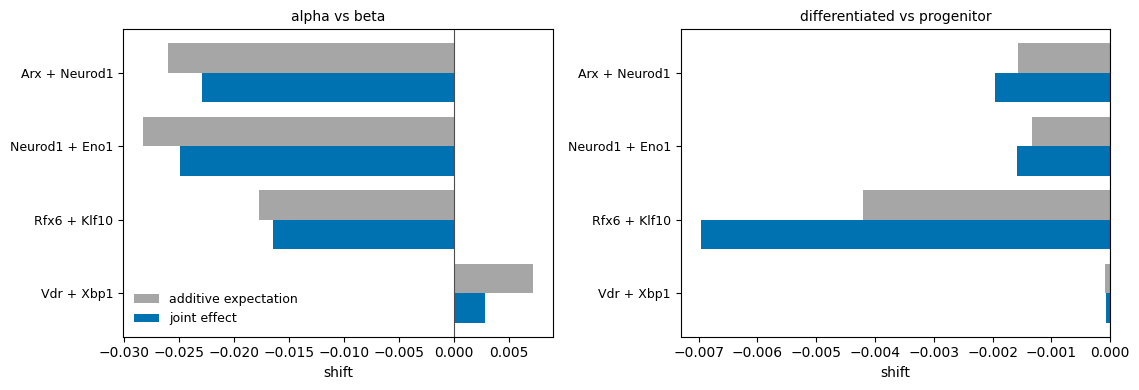

In [8]:
decisions = list(dict.fromkeys(epistasis["decision"]))
fig, axes_p = plt.subplots(1, len(decisions), figsize=(11.5, 4), sharey=False)
for ax_p, decision in zip(np.atleast_1d(axes_p), decisions):
    part = epistasis[epistasis["decision"] == decision]
    y = np.arange(len(part))
    ax_p.barh(y - 0.2, part["additive expectation"], 0.4,
              color="0.65", label="additive expectation")
    ax_p.barh(y + 0.2, part["joint effect"], 0.4, color="#0072B2", label="joint effect")
    ax_p.set_yticks(y); ax_p.set_yticklabels(part["pair"], fontsize=9)
    ax_p.invert_yaxis()
    ax_p.axvline(0, color="0.3", lw=0.8)
    ax_p.set_title(decision, fontsize=10)
    ax_p.set_xlabel("shift")
np.atleast_1d(axes_p)[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 3. What a departure from additivity is, and is not

Where the blue bar overshoots the gray one, the two regulators reinforce each other. Where it
falls short, they overlap: part of what one knockout would have done is already done by the other,
so removing both buys less than removing them separately would suggest.

Both patterns are predictions about the fitted network rather than measurements of a genetic
interaction. They say that in a system whose interactions were inferred from unperturbed cells,
these two perturbations do not compose additively. That is a hypothesis worth testing, and it is
not a result about epistasis in the genetic sense, which requires the double mutant to be made.

The paper is explicit about this, and reports that most of the pairs it displays fall in its
lowest tier of independent literature support. They are offered as candidates.

## 4. Scaling up

The screen behind the paper's combinatorial figure follows this exact calculation over a candidate
pool rather than a curated list. `sch.tl.pairwise_fate_bias` runs it, and
`sch.tl.double_knockout_matrix` assembles the full single-and-double matrix a heatmap is drawn
from. Both take a `workers` argument, because the evaluations are independent.

Filtering candidates on out-strength before pairing matters more here than anywhere else: the
number of pairs grows with the square of the pool, so admitting genes that cannot produce a
nonzero answer is quadratically wasteful.

## Where to go next

- **Single-gene knockouts** defines every quantity this tutorial reuses.
- **Reading the fitted system** explains where the out-strength filter comes from.